At redshift $z \approx 1.5$, ultra-compact massive galaxies and compact star-forming cores routinely achieve physical half-light radii under 1 kiloparsec, translating to angular sizes well below 0.1 arcseconds. 

We will model the Sersic profile of a compact early-type galaxy. See Sersic profile lecture: https://ned.ipac.caltech.edu/level5/March05/Graham/Graham2.html

In [90]:
import astropy.units as u
from astropy.modeling.models import Sersic2D
# Source: https://docs.astropy.org/en/stable/api/astropy.modeling.functional_models.Sersic2D.html

In [91]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import jv, kv
from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [92]:
# jn_zeros is a function that returns the zeros of the Bessel function of the first kind, 
# which are needed to find the roots for the LP01 mode in a step-index fibre
from scipy.special import jn_zeros  # NEW: needed to get the first zero of J0

In [93]:
from scipy.optimize import brentq
from scipy.optimize import fminbound

In [94]:
from dataclasses import dataclass
import pandas as pd

In [95]:
from joblib import Parallel, delayed
import os

In [96]:
def cutoff(l,m):
    """
    Utility  function which calculates the cutoff frequency Vc, and returns the normalised frequency (V) at cutoff V for
    a given mode l,m. 
    
    Arguments: 
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    
    Return value: 

    Vc: Normalised frequency at cutoff for the given mode, equals to the last zero of J_{l-1} for l>=1, 
    and Vc=0 for J_{m-1} for l=0.
    
    """

    if l >= 1: 
        Vc = jn_zeros(l - 1, m)[-1] # jn_zeros computes zeros of integer-order Bessel functions Jn. 
        return Vc # returns cutoff frequency of the mode (LP_lm with l>=1)
    elif l == 0: 
        if m == 1: 
            Vc = 0
            return Vc # returns cutoff frequency of the fundamental mode (LP01)
        else:
            Vc = jn_zeros(1, m - 1)[-1]
            return Vc # returns cutoff frequency of higher order modes (LP0m with m>1)
    else:
        raise ValueError("l must be >= 0")

In [97]:
def modes(V, l_max=5, m_max=5, v_margin=2e-3, az_sym_only=True): 
    """
    For each value of l, calculate the allowed values of m (if any). 
    Returns a list of modes that are supported by the fibre, sorted by their cutoff V-number.

    Arguments: 
    V: Normalised frequency of the fiber, float > 0
    l_max: Maximum azimuthal order to consider, integer >= 0
    m_max: Maximum radial order to consider, integer >= 1
    v_margin: Margin for checking mode existence at cutoff, to account for numerical precision issues. 
    az_sym_only: If True, only include modes with l=0 (azimuthally symmetric modes). If False, include all modes up to l_max. 
    
    Return value: 
    mode_list: A list of [l, m, Vc] for each mode that is supported by the fibre, where Vc is the cutoff V-number for that mode. 
    """ 
    if V <= 0: 
        raise ValueError("V must be >= 0")

    mode_list = []

    # loop over a range from l=0 to l_max, and for each l, loop over m=1 to m_max.
    for l in range(l_max + 1): 
        # if both conditions are met, we only consider modes with l=0, which are azimuthally symmetric.
        if az_sym_only and l != 0: 
            continue # skip modes with l != 0 if az_sym_only is True
        # no else needed, we just continue to the next l if the condition is met. if az_sym_only is False, we will consider all l values up to l_max, 
        # including those with l != 0.
        for m in range(1, m_max + 1): 
            V_c = cutoff(l, m) # calculate cutoff V-number for the mode (l,m)

            if V > V_c + v_margin: 
                mode_list.append([l, m, V_c])

            else: 
                break
    
    # A lambda function is an anonymous function in Python, which can take any number of arguments but can only have one expression. 
    # In this case, the lambda function is used as the key for sorting the mode_list. 
    mode_list.sort(key=lambda mode: mode[2])  # Sort by cutoff V-number

    return mode_list

In [98]:
def function_characteristic_eq(X, V, l): 
    """
    Function that equates to zero at the roots of the characteristic equation. 

    Arguments: 
    X: Normalised transverse propagation constant in the core, float > 0
    V: Normalised frequency of the fibre, float > 0
    Return value: 
    lhs - rhs: The difference between the left-hand side and right-hand side of the characteristic equation, which should be zero at the roots. 
    """
    # Calculate Y based on the relationship Y^2 = V^2 - X^2
    Y = np.sqrt(V**2 - X**2) # Y is the normalised transverse propagation constant in the cladding, and must be real for guided modes (X < V)

    if l > 0: 
        lhs = X * jv(l + 1, X) / jv(l, X)
        rhs = Y * kv(l + 1, Y) / kv(l, Y)
        return lhs - rhs 
    
    elif l == 0:
        lhs = X * jv(1, X) / jv(0, X)
        rhs = Y * kv(1, Y) / kv(0, Y)
        return lhs - rhs
    
    else:
        raise ValueError("l must be >= 0")

In [99]:
def find_root_XY(l, m, V, eps=np.finfo(float).eps):
    """
    Calculates the two transverse propagation constants X & Y for a given
    normalised frequency and LP mode (l,m).

    Arguments:
    V: Normalised frequency, float >= cutoff(l,m)
    l: Azimuthal order of the LP mode, integer >= 0
    m: Radial order of the LP mode, integer >= 1
    eps: Margin to avoid numerical issues near cutoff

    Returned values: 
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0
    """

    # This creates a one-variable function of X only.
    # V and l are "remembered" from the surrounding function.
    f = lambda X: function_characteristic_eq(X, V, l)

    # For all except LP01, Vc is positive. LP01 has cutoff Vc = 0.
    Vc_low = cutoff(l, m)

    if V <= Vc_low: 
        raise ValueError(f"V={V:.6f} is below cutoff for mode ({l},{m})")
    
    Vc_high = cutoff(l + 1, m) # cutoff frequency of the next azimuthal mode with the same radial order
    # We set the lower bound to be slightly above Vc_low to avoid numerical issues
    lower = Vc_low * (1 + eps)
    # Set the upper bound to be slightly below allowed upper limits to avoid numerical issues
    upper = min(Vc_high * (1 - eps), V * (1 - eps)) # between the Vc of the next mode and the maximum allowed by the fibre V
    X_root = brentq(f, lower, upper) # uses lambda function f to find the root in the specified interval
    Y_root = np.sqrt(V**2 - X_root**2)

    return X_root, Y_root

In [100]:
def lp_mode_field_2d(x, y, a, l, X_root, Y_root, angular="cos"): 
    """
    Calculate the 2D electric field distribution of an LP mode in a step-index fibre. 

    Arguments: 
    x: 2D array of x coordinates in physical units (e.g., microns)
    y: 2D array of y coordinates in physical units (e.g., microns)
    a: Core radius of the fibre, in the same units as x and y
    l: Azimuthal order of the LP mode, integer >= 0
    X_root: Normalised transverse propagation constant in the core, float > 0
    Y_root: Normalised transverse propagation constant in the cladding, float > 0

    Return value: 
    E_2d: 2D array of the electric field distribution of the specified LP mode at the given coordinates. 
    I_2d: 2D array of the intensity distribution (|E|^2) of the specified LP mode at the given coordinates.
    """

    r = np.sqrt(x**2 + y**2) # Calculate the radial distance from the center of the fibre
    phi = np.arctan2(y, x) # Calculate the angular coordinate in the 2D grid, arctan2 is tan^-1(y/x) 
    # but takes into account the signs of x and y to determine the correct quadrant 
    rho = r / a # Normalised radial coordinate

    E_mode = np.zeros_like(r, dtype=float)

    # Calculate the field distribution based on the LP mode
    # Angular part: 
    if l ==0:
        fphi = np.ones_like(phi) # For l=0, the angular part is constant so phi=0 for cos(l*phi) 
    else:
        if angular == "cos":
            fphi = np.cos(l * phi)
        elif angular == "sin": 
            fphi = np.sin(l * phi)
        else:
            raise ValueError("angular must be 'cos' or 'sin'")
        
        # At exactly r=0, the asymmetric modes should be zero
        fphi = np.where(r > 0, fphi, 0) # np.where chooses fphi where r>0, else if r!>0 it sets fphi to 0

    # Radial masks: 
    core = r <= a # Boolean mask for core region 
    cladding = r > a # Boolean mask for cladding region

    # 
    # Author's normalization convention:
    # core: J_l(u r/a) / J_l(u)
    # cladding: K_l(w r/a) / K_l(w)
    E_mode[core] = fphi[core] * jv(l, X_root * rho[core])
    
    Constant_C = jv(l, X_root) / kv(l, Y_root) # This constant ensures the field is continuous at r=a
    E_mode[cladding] = fphi[cladding] * Constant_C * kv(l, Y_root * rho[cladding]) 

    I_mode = np.abs(E_mode)**2

    return E_mode, I_mode

In [101]:
def diffraction_limited_E_field_at_fibre_2d(x, y, lam0, F_eff, alpha=0.0, E_S=1.0, decentre=None):
    """
    Diffraction-limited telescope image electric field evaluated
    on a 2D grid at the fibre input plane.

    Parameters
    ----------
    x, y : 2D arrays
        Cartesian coordinates at the fibre input plane [m].
        The fibre centre is assumed to be at x=0, y=0.
    lam0 : float
        Wavelength [m].
    F_eff : float
        Effective focal ratio at the fibre input plane.
    alpha : float
        Central obstruction ratio.
    E_S : float
        Overall field amplitude.
    decentre : None or tuple
        If None, the image is centred on the fibre.
        If (dx, dy), the image centre is shifted by dx, dy [m]
        relative to the fibre centre.

    Returns
    -------
    E_image : 2D array
        Electric field at the fibre input plane.
    I_image : 2D array
        Intensity at the fibre input plane.
    """

    if decentre is None:
        dx, dy = 0.0, 0.0
        r_image = np.sqrt(x**2 + y**2)

    else:
        dx, dy = decentre
        # Coordinates relative to the centre of the image/PSF
        x_shifted = x - dx
        y_shifted = y - dy # if we set phi=0, the vertical shift would become zero as we 
        # later set dy=rsin(phi)=r, assuming the shift is purely radial

        # The radial distance from the centre of the PSF is calculated using the coordinates
        r_image = np.sqrt(x_shifted**2 + y_shifted**2)

    # Compute s, the normalized radial coordinate in the image plane, which is used to calculate the Airy pattern.
    s = np.pi * r_image / (lam0 * F_eff)

    airy_term = np.divide(2 * j1(s), s, # Airy pattern term 2*J1(s)/s, which describes the diffraction pattern of a circular aperture.
        out=np.ones_like(s),
        where=s != 0   # to avoid division by zero at the centre of the PSF, where s=0. The limit of 2*j1(s)/s as s->0 is 1, which is consistent with the Airy pattern having a maximum value of 1 at the centre.
    )

    if alpha > 0:
        obstruction_term = np.divide(2 * j1(alpha * s), alpha * s,
            out=np.ones_like(s),
            where=(alpha * s) != 0   # to avoid division by zero at the centre of the PSF, where alpha * s = 0
        )
        E_image = E_S * (airy_term - alpha**2 * obstruction_term)
    else:
        E_image = E_S * airy_term

    I_image = np.abs(E_image)**2

    return E_image, I_image

In [102]:
def coupling_efficiency_2d(E_image, E_mode, x_1d, y_1d): 
    """
    Calculate the 2D coupling efficiency between an image-plane electric field
    and a fibre mode electric field.

    Input:
    E_image: 2D electric field of the image at the fibre input plane
    E_mode: 2D electric field of the fibre LP mode
    x_1d: 1D x-coordinate array used to make the 2D grid [m]
    y_1d: 1D y-coordinate array used to make the 2D grid [m]

    Output:
    eta: coupling efficiency
    numerator = |∫∫ E_image * conj(E_mode) dx dy|^2
    denominator = ∫∫ |E_image|^2 dx dy * ∫∫ |E_mode|^2 dx dy
    """

    # The integrand inside the integral
    overlap_integrand = E_image * np.conjugate(E_mode)

    # First integrate along the direction of x: 
    overlap_x = integrate.simpson(overlap_integrand, x=x_1d, axis=1)
    overlap = integrate.simpson(overlap_x, x=y_1d) 

    # Power is the integral of the electric field amplitude intensity. 
    # The power in each electric field are normalisation factors when we take the product of 
    # power in image field and power in mode field
    P_image_x = integrate.simpson(np.abs(E_image)**2, x=x_1d, axis=1)
    P_image = integrate.simpson(P_image_x, x=y_1d)
    P_mode_x = integrate.simpson(np.abs(E_mode)**2, x=x_1d, axis=1)
    P_mode = integrate.simpson(P_mode_x, x=y_1d)

    # Calculate the coupling efficiency
    numerator = np.abs(overlap)**2
    denominator = P_image * P_mode

    eta = numerator / denominator

    return eta, numerator, denominator

In [103]:
def prepare_modes_2d(
    x, y,
    a, NA, lam0,
    az_sym=True,
    mode_case="few_mode"
):
    """
    Prepare fibre mode fields for a fixed core radius.

    Parameters:
    x, y: 2D coordinate arrays at the fibre input plane [m]
    a: Core radius of the fibre [m]
    NA: Numerical aperture of the fibre
    lam0: Wavelength [m]
    az_sym: If True, only include azimuthally symmetric modes (l=0). If False, 
    include all modes up to l_max.
    mode_case:
        "smf"      -> only LP01
        "few_mode" -> all supported modes, optionally restricted by az_sym
    
    Returns value: 
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    Includes l, m, cutoff_V, X_root, Y_root, angular, E_mode, I_mode for each mode.
    """

    V = 2 * np.pi * a * NA / lam0

    if mode_case == "smf": # note if the maximum radius leads to V > 2.405, the fibre would support more modes, the case would be impractical
        allmodes = [[0, 1, 0.0]]
        if V > 2.405:
            print(f"Warning: V={V:.3f} > 2.405, the fibre would support more modes than just LP01, the 'smf' case may be impractical.")

    elif mode_case == "few_mode":
        allmodes = modes(V, az_sym_only=az_sym) # compute all modes supported by the fibre based on the V number

        if az_sym:
            allmodes = [mode for mode in allmodes if mode[0] == 0] # only keep azimuthally symmetric modes if az_sym is True

    else:
        raise ValueError("mode_case must be 'smf' or 'few_mode'")

    # Create a list to store the prepared modes
    prepared_modes = []
    # Loop through each mode created from modes() and compute the corresponding electric field distribution
    for mode in allmodes:
        l, m, cutoff_V = mode

        try:
            X_root, Y_root = find_root_XY(l, m, V) # find X_root and Y_root for the mode with l,m, at the given V estimated from a (not Vc)
        except ValueError:
            continue

        if l == 0:
            angular_list = ["cos"] # only one polarisaton for azimuthally symmetric modes, technically for l=0 the angular part is just a constant (cos(0)=1)
        else:
            angular_list = ["cos", "sin"] # both cos and sin polarisations for asymmetric modes

        for angular in angular_list:
            E_mode, I_mode = lp_mode_field_2d(
                x, y,
                a=a,
                l=l,
                X_root=X_root,
                Y_root=Y_root,
                angular=angular
            )

            prepared_modes.append({
                "l": l,
                "m": m,
                "cutoff_V": cutoff_V,
                "X_root": X_root,
                "Y_root": Y_root,
                "angular": angular,
                "E_mode": E_mode,
                "I_mode": I_mode
            })

    return prepared_modes

In [104]:
def total_eff_2d(
    prepared_modes,
    x, y, x_1d, y_1d,
    lam0, F_eff, alpha,
    decentre=None,
    E_S=1.0
):
    """
    Calculates the total 2D coupling efficiency using precomputed fibre modes.
    Only E_image changes with focal ratio F.

    Parameters:
    prepared_modes: A list of dictionaries containing precomputed fibre mode fields and their properties.
    x, y: 2D coordinate arrays at the fibre input plane [m]
    x_1d, y_1d: 1D coordinate arrays used to make the 2D grid [m]
    lam0: Wavelength [m]
    F_eff: Effective focal ratio to be optimised
    alpha: Divergence angle [rad]
    decentre: Decentre of the image field [m]
    E_S: Source electric field amplitude [V/m]
    """

    E_image, I_image = diffraction_limited_E_field_at_fibre_2d(
        x, y,
        lam0=lam0,
        F_eff=F_eff,
        alpha=alpha,
        E_S=E_S,
        decentre=decentre
    )

    # begin with zero efficiency when we haven't started accumulating eta for any modes
    total = 0.0
    mode_results = [] # array of dictionaries containing mode results

    # for each existing modes in the prepared_modes list, calculate eta at that mode
    for mode in prepared_modes:
        eta, num, den = coupling_efficiency_2d(
            E_image,
            mode["E_mode"],
            x_1d,
            y_1d
        )

        total += eta # accumulate coupling efficiency at each mode to the total coupling efficiency

        mode_results.append({
            "l": mode["l"],
            "m": mode["m"],
            "cutoff_V": mode["cutoff_V"],
            "X_root": mode["X_root"],
            "Y_root": mode["Y_root"],
            "angular": mode["angular"],
            "eta": eta
        })

    return total, mode_results

In [105]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 
# fibre core radius
a = 5e-6 
# numerical aperture of fibre
NA = 0.1 

# Calculate the normalised frequency (V-number) of the fibre
V = 2 * pi * (a / lam0) * NA
print(f"V-number of the fibre: {V:.2f}")

V-number of the fibre: 2.09


In [106]:
V_max_single = 2.405 # The cutoff V-number for single-mode operation in a step-index fibre
a_max_single = V_max_single * lam0 / (2 * np.pi * NA)
print(f"Maximum core radius for single-mode operation: {a_max_single*1e6:.20f} microns")

Maximum core radius for single-mode operation: 5.74151457204012416469 microns


In [107]:
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
Magnification = F_fibre / 49.9
F_focus = 49.9
D_M1 = 8.0
D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha_vlt = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter
rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane
plate_scale_demag = plate_scale_coude / Magnification # arcsec / metre at the demagnified fibre input plane

In [108]:
print(f"Plate scale at the Coudé focus: {plate_scale_coude*1e-3:.2f} arcsec/mm")

Plate scale at the Coudé focus: 0.52 arcsec/mm


In [109]:
core_radius_range_test = np.arange(2.5e-6, 5.74e-6 + 0.01e-6, 0.01e-6) # range of core radius to test, from 2.5 microns to 5.7415 microns, in steps of 0.01 microns. Note arange is exclusive of the upper limit, so we add 0.01e-6 to include 5.74e-6 in the range. 
lam0 = 1.5e-6 # wavelength of beam in vacuum 

In [110]:
path = '/Users/tliu/oh_suppression/data/data_CANDELS_structural_param_galaxies/ID18941_matched_rows.csv'
df = pd.read_csv(path)
df

,Fld,F,ID,W,RAJ2000,DEJ2000,Q,mag,e_mag,r,e_r,n,e_n,q,PA,S_N,COSMOS,GOODS,recno
0,G,H,18941,W,53.152779,-27.750511,0,22.224,0.009,0.101,0.002,3.335,0.130,0.514,-88.7,327.52,0,1,90805
1,G,J,18941,W,53.152779,-27.750511,0,22.548,0.009,0.097,0.002,3.518,0.149,0.515,-88.9,312.57,0,1,125735
2,G,Y,18941,W,53.152779,-27.750511,0,22.886,0.010,0.094,0.002,3.073,0.150,0.472,-86.7,272.72,0,1,160665


In [111]:
n_sersic = 3.335 # sersic index, n>0.36
Re_arcsec = 0.101 # half light radius in arcseconds
q_param = 0.514 # projected axis ratio of the galaxy, b/a, where b is the semi-minor axis and a is the semi-major axis. This is used to calculate the effective radius in the direction of the fibre input plane.
# PA = 0 # assumed to be 0 for simplicity, but can be adjusted based on the orientation of the galaxy in the sky.
PA_deg = -88.7
ellip = 1 - q_param # ellipticity of the galaxy, defined as 1 - (b/a)

In [112]:
# Sersic profile has a scaling constant b_n, for n>0.36, b_n can be approximated as b_n = 2n - 1/3 + 4/(405n) + 46/(25515n^2) + 131/(1148175n^3) 
# - 2194697/(30690717750n^4)
b_n = 2 * n_sersic - 1/3 + 4/(405*n_sersic) + 46/(25515*n_sersic**2) + 131/(1148175*n_sersic**3) - 2194697/(30690717750*n_sersic**4)

The intensity of a profile of galaxy at the image plane: 

$$
I(R) = I_e \exp\left[
-b_n \left(
\left(\frac{R}{R_e}\right)^{1/n} - 1
\right)
\right]
$$

At the fibre front in grids: 

$$
I(x,y) = I_e \exp\left[
-b_n \left(
\left(\frac{R_{\mathrm{ell}}(x,y)}{R_e}\right)^{1/n} - 1
\right)
\right],
$$

For galaxy with a elliptical radius $R_{ell}$: 

$$
R_{\mathrm{ell}}(x,y)
=
\sqrt{
x'^2 + \left(\frac{y'}{q}\right)^2
}.
$$

where $q = \frac{b}{a}$

In [113]:
Sersic2D?

Init signature:
Sersic2D(
    amplitude=1,
    r_eff=1,
    n=4,
    x_0=0,
    y_0=0,
    ellip=0,
    theta=0.0,
    **kwargs,
)
Docstring:     
Two dimensional Sersic surface brightness profile.

Parameters
----------
amplitude : float
    Surface brightness at ``r_eff``.
r_eff : float
    Effective (half-light) radius.
n : float
    Sersic index controlling the shape of the profile. Particular
    values of ``n`` are equivalent to the following profiles:

        * n=4 : `de Vaucouleurs <https://en.wikipedia.org/wiki/De_Vaucouleurs%27s_law>`_ :math:`r^{1/4}` profile
        * n=1 : Exponential profile
        * n=0.5 : Gaussian profile
x_0 : float, optional
    x position of the center.
y_0 : float, optional
    y position of the center.
ellip : float, optional
    Ellipticity of the isophote, defined as 1.0 minus the ratio of
    the lengths of the semimajor and semiminor axes:

    .. math:: ellip = 1 - \frac{b}{a}
theta : float or `~astropy.units.Quantity`, optional
    The rota

In [114]:
# Fibre front grid in metres

r_max = 125e-6 # maximum radius of the CLADDING region to be considered in the 2D grid, in meters
n_grid = 1000 

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [115]:
FOV_test = plate_scale_demag * 2 * r_max
FOV_test_smf = plate_scale_demag * 2 * 5.7e-6
print(f"Test FOV: {FOV_test:.4f} arcsec")
print(f"Test FOV for SMF: {FOV_test_smf:.4f} arcsec")

Test FOV: 1.2956 arcsec
Test FOV for SMF: 0.0591 arcsec


In [116]:
# Angular grid for the Sersic profile, in radians

# angular_extent = 0.5 # arcsec (I should probably find the FOV of a 125e-6m light bucket)
angular_extent = 1.30/2 # arcsec, which is half of the FOV of a 125e-6m light bucket at the Coudé focus, based on the plate scale calculated above.

x_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)
y_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)

x_arcsec, y_arcsec = np.meshgrid(x_arcsec_1d, y_arcsec_1d)

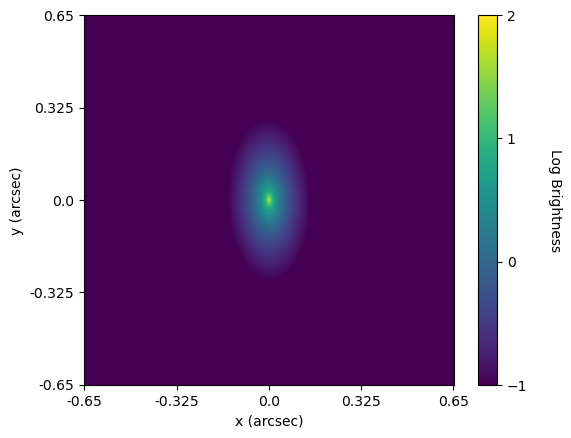

In [117]:
model_cent = Sersic2D(amplitude=1, r_eff = Re_arcsec, n = n_sersic, x_0=0, y_0=0, ellip=ellip, theta=np.radians(PA_deg))

# img is a numpy array of the Sersic profile evaluated at each point in the 2D grid defined by x_arcsec and y_arcsec. 
img = model_cent(x_arcsec, y_arcsec)
log_img = np.log10(img)

fig, ax = plt.subplots()
im = ax.imshow(log_img, origin='lower', interpolation='nearest',
               vmin=-1, vmax=2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Log Brightness', rotation=270, labelpad=25)
# Set ticks in arcseconds for the x and y axes
ax.set_xticks(np.linspace(0, n_grid-1, 5))
ax.set_xticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
ax.set_yticks(np.linspace(0, n_grid-1, 5))
ax.set_yticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
cbar.set_ticks([-1, 0, 1, 2])
plt.xlabel('x (arcsec)')
plt.ylabel('y (arcsec)')
plt.show()

In [118]:
# model_cent?

In [119]:
angular_extent_smf = 0.0591/2 # arcsec, which is half of the FOV of a 125e-6m light bucket at the Coudé focus, based on the plate scale calculated above.

x_arcsec_1d_smf = np.linspace(-angular_extent_smf, angular_extent_smf, n_grid)
y_arcsec_1d_smf = np.linspace(-angular_extent_smf, angular_extent_smf, n_grid)

x_arcsec_smf, y_arcsec_smf = np.meshgrid(x_arcsec_1d_smf, y_arcsec_1d_smf)

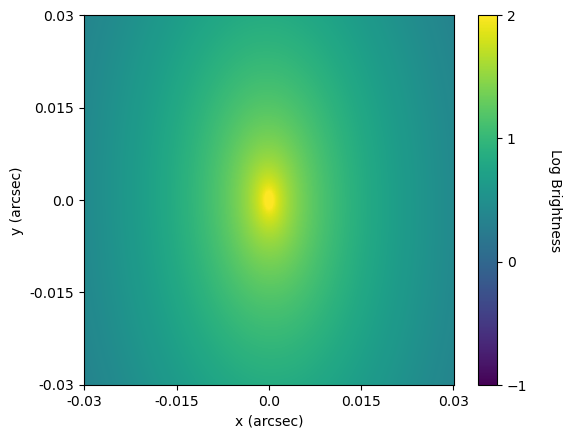

In [120]:
img_smf = model_cent(x_arcsec_smf, y_arcsec_smf)
log_img_smf = np.log10(img_smf)

fig, ax = plt.subplots()
im = ax.imshow(log_img_smf, origin='lower', interpolation='nearest',
               vmin=-1, vmax=2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Log Brightness', rotation=270, labelpad=25)
# Set ticks in arcseconds for the x and y axes
ax.set_xticks(np.linspace(0, n_grid-1, 5))
ax.set_xticklabels(np.round(np.linspace(-angular_extent_smf, angular_extent_smf, 5), 3))
ax.set_yticks(np.linspace(0, n_grid-1, 5))
ax.set_yticklabels(np.round(np.linspace(-angular_extent_smf, angular_extent_smf, 5), 3))
cbar.set_ticks([-1, 0, 1, 2])
plt.xlabel('x (arcsec)')
plt.ylabel('y (arcsec)')
plt.show()

## Coupling efficiency as a function of decentred source

In [121]:
def eta_psf_vs_decentre_position_2d(
        prepared_modes, 
        x, y, x_1d, y_1d, 
        lam0, F_eff, alpha, 
        decentre_array, 
        E_S = 1.0, 
        direction_angle = 0.0
):
    """
    Calculate the coupling efficiency of a point source  as a function to its decentre relative 
    to the fibre. 

    Parameters: 
    prepared_modes: the pre-computed fibre modes containing eigenfield information for ONE core radius

    decentre_array: array of image positions relative to the fibre centre

    direction_angle: the angle of offset direction in the x-y grid plane
    Assuming angle is zero for a circularly symmetric aperature
    """

    eta_psf = [] # prepare array of eta_psf for each decentre coordinate
    mode_results_all = [] # not required but returns the fields of eigenmodes

    for r in decentre_array: # r is distance to centre
        dx = r * np.cos(direction_angle) # cos(0)=1, we are varying in the x direction
        dy = r * np.sin(direction_angle) # sin(0)=0 

        eta_total, mode_results = total_eff_2d(
            prepared_modes, 
            x, y, x_1d, y_1d, 
            lam0=lam0, 
            F_eff=F_eff, 
            alpha=alpha, 
            decentre=(dx, dy),
            E_S=E_S
        )

        eta_psf.append(eta_total)
        mode_results_all.append(mode_results)

    eta_psf = np.array(eta_psf)

    return eta_psf, mode_results_all


In [122]:
# Only test for a single normalised frequency at r=5.7microns for my first test of decentred position
prepared_smf_mode_5p7micron = prepare_modes_2d(
                                x, y,
                                a=5.7e-6, 
                                NA=NA, 
                                lam0=lam0, 
                                az_sym=True, 
                                mode_case="few_mode"
                            )


In [123]:
prepared_smf_mode_5p7micron

[{'l': 0,
  'm': 1,
  'cutoff_V': 0,
  'X_root': 1.6421672078395666,
  'Y_root': np.float64(1.7331965738385287),
  'angular': 'cos',
  'E_mode': array([[2.09733057e-24, 2.21431445e-24, 2.33769711e-24, ...,
          2.33769711e-24, 2.21431445e-24, 2.09733057e-24],
         [2.21431445e-24, 2.33795179e-24, 2.46835925e-24, ...,
          2.46835925e-24, 2.33795179e-24, 2.21431445e-24],
         [2.33769711e-24, 2.46835925e-24, 2.60618405e-24, ...,
          2.60618405e-24, 2.46835925e-24, 2.33769711e-24],
         ...,
         [2.33769711e-24, 2.46835925e-24, 2.60618405e-24, ...,
          2.60618405e-24, 2.46835925e-24, 2.33769711e-24],
         [2.21431445e-24, 2.33795179e-24, 2.46835925e-24, ...,
          2.46835925e-24, 2.33795179e-24, 2.21431445e-24],
         [2.09733057e-24, 2.21431445e-24, 2.33769711e-24, ...,
          2.33769711e-24, 2.21431445e-24, 2.09733057e-24]],
        shape=(1000, 1000)),
  'I_mode': array([[4.39879550e-48, 4.90318850e-48, 5.46482779e-48, ...,
        

In [130]:
decentre_array_cladding = np.linspace(0, r_max, 500) # array of decentre positions from 0 to r_max, in meters

eta_psf_clad_5p7_decent_array, mode_result_single_5p7_clad = eta_psf_vs_decentre_position_2d(
    prepared_smf_mode_5p7micron,
    x, y, x_1d, y_1d,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha_vlt,
    decentre_array=decentre_array_cladding,
    E_S=1.0,
    direction_angle=0.0
)

In [131]:
eta_psf_clad_5p7_decent_array

array([7.27335035e-01, 7.25832057e-01, 7.21339514e-01, 7.13906299e-01,
       7.03613026e-01, 6.90570744e-01, 6.74919164e-01, 6.56824445e-01,
       6.36476578e-01, 6.14086424e-01, 5.89882455e-01, 5.64107270e-01,
       5.37013950e-01, 5.08862321e-01, 4.79915195e-01, 4.50434657e-01,
       4.20678471e-01, 3.90896661e-01, 3.61328328e-01, 3.32198752e-01,
       3.03716840e-01, 2.76072923e-01, 2.49436967e-01, 2.23957196e-01,
       1.99759131e-01, 1.76945073e-01, 1.55593983e-01, 1.35761780e-01,
       1.17482004e-01, 1.00766831e-01, 8.56083866e-02, 7.19803351e-02,
       5.98396815e-02, 4.91287480e-02, 3.97772724e-02, 3.17045804e-02,
       2.48217829e-02, 1.90339529e-02, 1.42422393e-02, 1.03458782e-02,
       7.24406904e-03, 4.83768459e-03, 3.03079359e-03, 1.73197738e-03,
       8.55429573e-04, 3.21832923e-04, 5.90135118e-05, 2.37740605e-06,
       9.51398358e-05, 2.88361125e-04, 5.40807154e-04, 8.18654989e-04,
       1.09506641e-03, 1.34965343e-03, 1.56786054e-03, 1.74028825e-03,
      

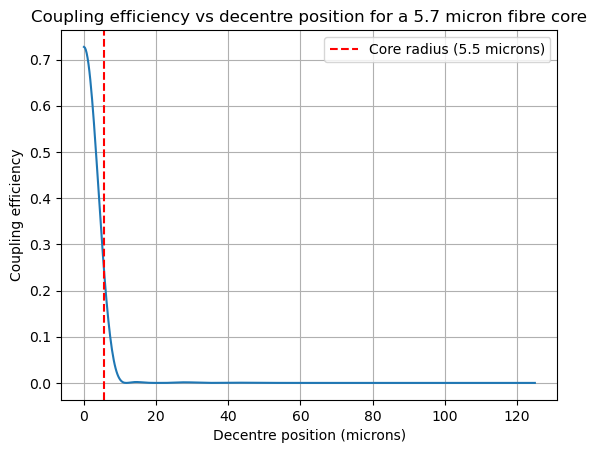

In [155]:
plt.plot(decentre_array_cladding*1e6, eta_psf_clad_5p7_decent_array)
plt.xlabel("Decentre position (microns)")
plt.ylabel("Coupling efficiency")
plt.title("Coupling efficiency vs decentre position for a 5.7 micron fibre core")
plt.axvline(5.5, color='r', linestyle='--', label='Core radius (5.5 microns)')
plt.legend()
plt.grid()

In [146]:
radial_vec1d = decentre_array_cladding
eta_vec1d = eta_psf_clad_5p7_decent_array

R = np.sqrt(x**2 + y**2)

eta_psf_dr_map_2d = np.interp(R.ravel(), radial_vec1d, eta_vec1d, left=eta_vec1d[0], right=eta_vec1d[-1]).reshape(R.shape)

print(f"eta_psf_dr_map_2d shape: {eta_psf_dr_map_2d.shape}, R shape: {R.shape}")

eta_psf_dr_map_2d shape: (1000, 1000), R shape: (1000, 1000)


This is a map showing what the coupling efficiency would be if it is decentred to that position: 

Text(0.5, 1.0, 'Coupling Efficiency Map for a 5.7 µm Core')

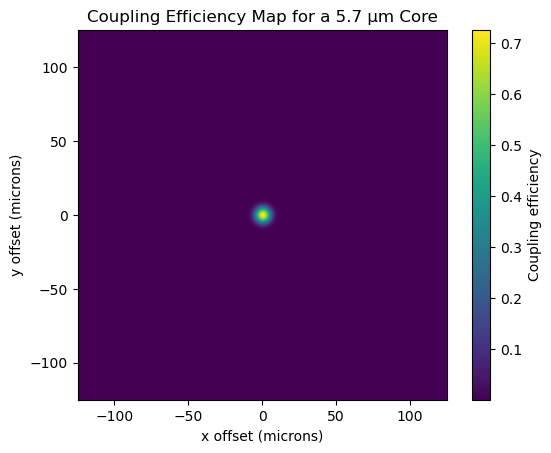

In [147]:
plt.imshow(eta_psf_dr_map_2d, origin='lower', extent=(-r_max*1e6, r_max*1e6, -r_max*1e6, r_max*1e6))
plt.colorbar(label='Coupling efficiency')
plt.xlabel("x offset (microns)")
plt.ylabel("y offset (microns)")
plt.title("Coupling Efficiency Map for a 5.7 µm Core")

In [148]:
def radial_efficiency_to_2d(decentre_array, eta_point_souorce, x, y, fibre_x=0.0, fibre_y=0.0):
    """
    Convert a radial efficiency profile to a 2D efficiency map.

    Parameters:
    decentre_array: 1D array of radial distances from the fibre centre [m]
    eta_point_source: 1D array of coupling efficiencies corresponding to decentre_array
    x, y: 2D coordinate arrays at the fibre input plane [m]
    fibre_x, fibre_y: coordinates of the fibre centre in the x-y grid [m]

    Returns:
    eta_2d: 2D array of coupling efficiencies at each point in the x-y grid
    """

    # Calculate the radial distance from the fibre centre for each point in the grid
    R = np.sqrt((x - fibre_x)**2 + (y - fibre_y)**2)

    # Interpolate the radial efficiency profile onto the 2D grid
    eta_map_2d = np.interp(R.ravel(), decentre_array, eta_point_souorce, left=eta_point_souorce[0], right=eta_point_souorce[-1]).reshape(R.shape)

    return eta_map_2d


In [149]:
def eta_extended_source_2d(
    eta_map_2d,
    galaxy_brightness_2d,
    x_1d,
    y_1d,
):
    """
    Calculate the coupling efficiency of an incoherent extended source
    into a fibre.

    Parameters
    ----------
    eta_map_2d : 2D array
        Point-source coupling efficiency evaluated across the x-y grid.

    galaxy_brightness_2d : 2D array
        Linear galaxy brightness distribution evaluated on the same grid.

    x_1d, y_1d : 1D arrays
        Coordinates of the x and y grid axes.

    Returns
    -------
    eta_extended : float
        Brightness-weighted coupling efficiency of the extended source.
    """

    weighted_function = (
        eta_map_2d
        * galaxy_brightness_2d
    )

    # First integrate along x, then along y
    weighted_sum = integrate.simpson(
        integrate.simpson(
            weighted_function,
            x=x_1d,
            axis=1,
        ),
        x=y_1d,
    )

    total_brightness = integrate.simpson(
        integrate.simpson(
            galaxy_brightness_2d,
            x=x_1d,
            axis=1,
        ),
        x=y_1d,
    )

    eta_extended = weighted_sum / total_brightness

    return eta_extended

In [150]:
eta_galaxy_cladding_5p7 = eta_extended_source_2d(
    eta_map_2d=eta_psf_dr_map_2d,
    galaxy_brightness_2d=img,
    x_1d=x_1d,
    y_1d=y_1d,
)

In [151]:
eta_galaxy_cladding_5p7

np.float64(0.15049211553828043)

In [152]:
decentre_array_core = np.linspace(0, 5.7e-6, 500) # array of decentre positions from 0 to 5.7 microns, in meters

eta_psf_core_5p7_decent_array, mode_result_single_5p7_core = eta_psf_vs_decentre_position_2d(
    prepared_smf_mode_5p7micron,
    x, y, x_1d, y_1d,
    lam0=lam0,
    F_eff=F_fibre,
    alpha=alpha_vlt,
    decentre_array=decentre_array_core,
    E_S=1.0,
    direction_angle=0.0
)

Text(0.5, 1.0, 'Coupling efficiency vs decentre position for a 5.7 micron fibre core')

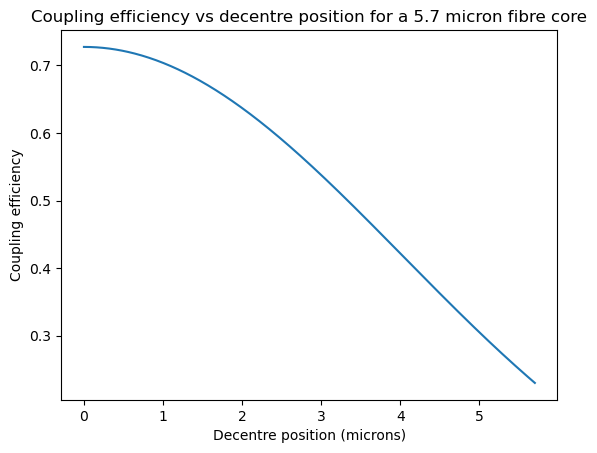

In [153]:
plt.plot(decentre_array_core*1e6, eta_psf_core_5p7_decent_array)
plt.xlabel("Decentre position (microns)")
plt.ylabel("Coupling efficiency")
plt.title("Coupling efficiency vs decentre position for a 5.7 micron fibre core")

In [161]:
x_5p7micron_1d = np.linspace(-5.7e-6, 5.7e-6, 1000) # 1D array of x coordinates from -5.7 microns to 5.7 microns
y_5p7micron_1d = np.linspace(-5.7e-6, 5.7e-6, 1000) # 1D array of y coordinates from -5.7 microns to 5.7 microns
x_5p7micron, y_5p7micron = np.meshgrid(x_5p7micron_1d, y_5p7micron_1d) # 2D grid of x and y coordinates

In [162]:
eta_psf_dr_core_map_2d = radial_efficiency_to_2d(decentre_array_core, eta_psf_core_5p7_decent_array, x_5p7micron, y_5p7micron)

Text(0.5, 1.0, 'Coupling efficiency map for a 5.7 micron fibre core')

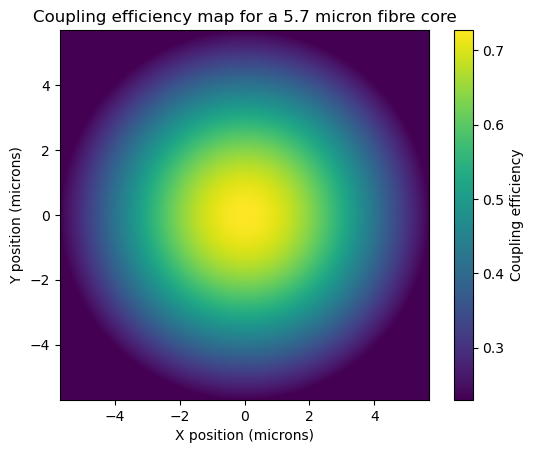

In [170]:
plt.imshow(eta_psf_dr_core_map_2d, origin='lower', extent=(-5.7, 5.7, -5.7, 5.7), cmap='viridis')
plt.colorbar(label='Coupling efficiency')
plt.xlabel("X position (microns)")
plt.ylabel("Y position (microns)")
plt.title("Coupling efficiency map for a 5.7 micron fibre core")

In [166]:
eta_galaxy_core_5p7 = eta_extended_source_2d(
    eta_map_2d=eta_psf_dr_core_map_2d,
    galaxy_brightness_2d=img,
    x_1d=x_1d,
    y_1d=y_1d,
)

In [167]:
eta_galaxy_core_5p7

np.float64(0.6764947280357749)